# Dataset Analysis for Primary_Emotions.xlsx

This notebook analyzes the poem dataset to count poems per language, emotion, and calculate average lengths.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

## 1. Load Data

In [2]:
file_path = '/Users/hemishjain22/Desktop/Hackathons/hack4healtj/round1/Primary_Emotions.xlsx'
try:
    df = pd.read_excel(file_path)
    print("Dataset loaded successfully.")
    display(df.head())
    print(f"Total records: {len(df)}")
except FileNotFoundError:
    print(f"File not found at {file_path}. Please check the path.")

Dataset loaded successfully.


,Sl.No.,Poem,Source,Primary
0,1,அகர முதல எழுத்தெல்லாம் ஆதி பகவன் முதற்றே உலகு.,Tamil,Reverence
1,2,கற்றதனால் ஆய பயனென்கொல் வாலறிவன் நற்றாள் தொழாஅ...,Tamil,Reverence
2,3,மலர்மிசை ஏகினான் மாணடி சேர்ந்தார் நிலமிசை நீடு...,Tamil,Reverence
3,4,வேண்டுதல்வேண் டாமை இலானடி சேர்ந்தார்க்கு யாண்ட...,Tamil,Reverence
4,5,இருள்சேர் இருவினையும் சேரா இறைவன் பொருள்சேர் ப...,Tamil,Reverence


Total records: 4124


## 2. Data Quality Check
Checking for duplicates and missing values.

In [3]:
duplicates = df['Poem'].duplicated().sum()
missing_values = df.isnull().sum()

print(f"Duplicate Poems: {duplicates}")
print("\nMissing Values per Column:")
print(missing_values)

if duplicates == 0 and missing_values.sum() == 0:
    print("\n✅ Data Clean: No duplicates or missing values found.")
else:
    print("\n⚠️ Data Issues Found!")

Duplicate Poems: 0

Missing Values per Column:
Sl.No.     0
Poem       0
Source     0
Primary    0
dtype: int64

✅ Data Clean: No duplicates or missing values found.


## 3. Poems per Language (Source)

Poems per Language:
Source
Hindi      1600
Tamil      1330
Bengali    1194
Name: count, dtype: int64


/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_15610/569181376.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_counts.index, y=lang_counts.values, palette='viridis')


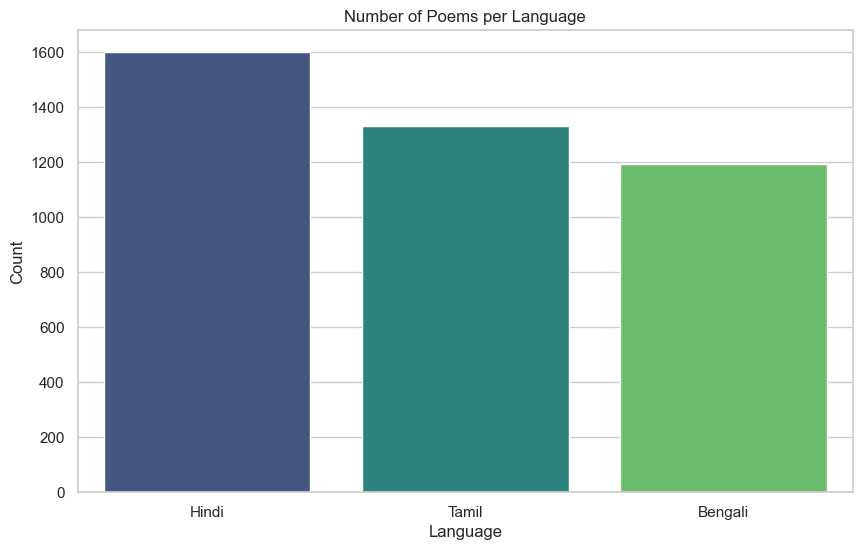

In [4]:
lang_counts = df['Source'].value_counts()
print("Poems per Language:")
print(lang_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=lang_counts.index, y=lang_counts.values, palette='viridis')
plt.title('Number of Poems per Language')
plt.ylabel('Count')
plt.xlabel('Language')
plt.show()

## 4. Poems per Emotion (Primary)

Top 10 Emotions:
Primary
Longing       719
Melancholy    555
Sadness       543
Love          302
Happiness     200
Philosophy    159
Caution       140
Fear          119
Patriotism    117
Nature        107
Name: count, dtype: int64


/var/folders/96/r1xph1zx3pz34nbqv3j9t8kw0000gn/T/ipykernel_15610/3254710481.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=emotion_counts.index, x=emotion_counts.values, palette='magma')


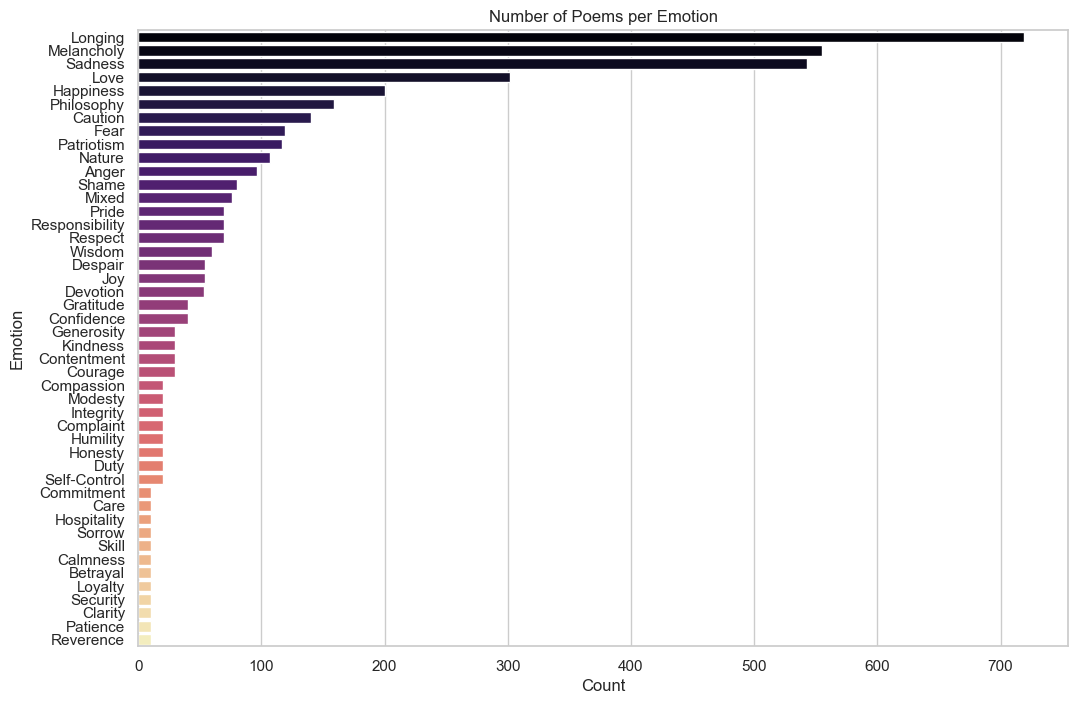

In [5]:
emotion_counts = df['Primary'].value_counts()
print("Top 10 Emotions:")
print(emotion_counts.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(y=emotion_counts.index, x=emotion_counts.values, palette='magma')
plt.title('Number of Poems per Emotion')
plt.xlabel('Count')
plt.ylabel('Emotion')
plt.show()

## 5. Average Poem Length
Calculating length by characters and words.

Average Poem Length (Characters): 344.75
Average Poem Length (Words): 55.49


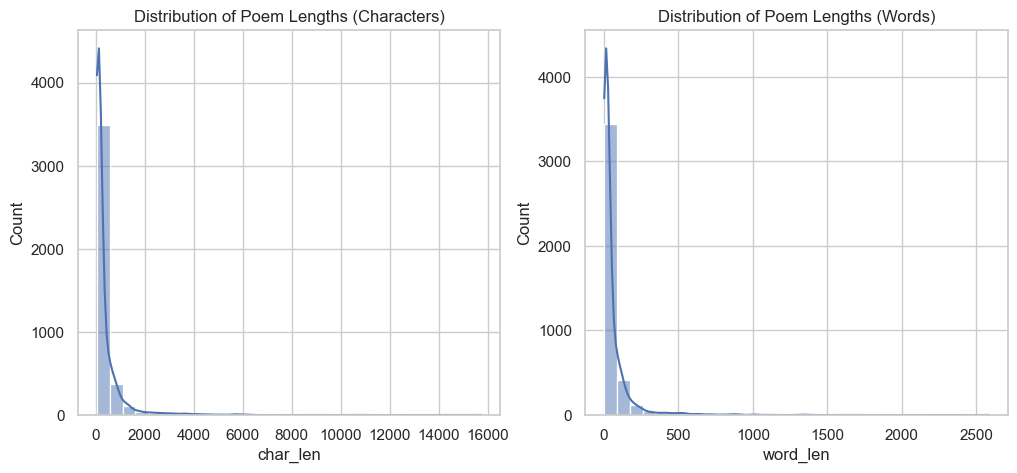

In [6]:
df['char_len'] = df['Poem'].astype(str).str.len()
df['word_len'] = df['Poem'].astype(str).str.split().str.len()

avg_char = df['char_len'].mean()
avg_word = df['word_len'].mean()

print(f"Average Poem Length (Characters): {avg_char:.2f}")
print(f"Average Poem Length (Words): {avg_word:.2f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['char_len'], bins=30, kde=True)
plt.title('Distribution of Poem Lengths (Characters)')

plt.subplot(1, 2, 2)
sns.histplot(df['word_len'], bins=30, kde=True)
plt.title('Distribution of Poem Lengths (Words)')
plt.show()

## 6. Label Names

In [7]:
labels = df['Primary'].unique()
print(f"Total Unique Labels: {len(labels)}")
print("Label Names:")
print(labels)

Total Unique Labels: 46
Label Names:
['Reverence' 'Gratitude' 'Respect' 'Duty' 'Commitment' 'Love' 'Joy'
 'Pride' 'Contentment' 'Compassion' 'Kindness' 'Generosity' 'Hospitality'
 'Modesty' 'Humility' 'Patience' 'Calmness' 'Integrity' 'Wisdom' 'Fear'
 'Self-Control' 'Caution' 'Honesty' 'Shame' 'Responsibility' 'Confidence'
 'Clarity' 'Courage' 'Security' 'Loyalty' 'Anger' 'Betrayal' 'Care'
 'Skill' 'Sorrow' 'Longing' 'Complaint' 'Sadness' 'Patriotism' 'Nature'
 'Happiness' 'Philosophy' 'Devotion' 'Mixed' 'Melancholy' 'Despair']
